# EDA orientada ao sistema de recomendação

## Problema

Usar o histórico de avaliações para recomendar filmes ainda não avaliados pelos usuários.

Nesta primeira versão, ratings são tratados como **feedback explícito**. Notas iguais ou maiores que 4 também são consideradas um sinal de relevância para futuras métricas Top-K.

## Perguntas

- Quão esparsa é a matriz usuário-filme?
- Como notas e interações estão distribuídas?
- Há usuários ou filmes com pouco histórico?
- Existe concentração de interações em poucos filmes?
- Como gêneros, tags e tempo poderão ser usados pelo modelo?

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
plt.style.use("seaborn-v0_8-whitegrid")

## Carregamento

Os caminhos são resolvidos a partir da raiz do projeto. Os nomes das colunas são padronizados sem alterar os arquivos brutos.

In [2]:
def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "data" / "raw").is_dir():
            return candidate
    raise FileNotFoundError("Não foi possível localizar data/raw.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

movies = pd.read_csv(RAW_DATA_DIR / "movies.csv").rename(
    columns={"movieId": "movie_id"}
)
ratings = pd.read_csv(RAW_DATA_DIR / "ratings.csv").rename(
    columns={"userId": "user_id", "movieId": "movie_id"}
)
tags = pd.read_csv(RAW_DATA_DIR / "tags.csv").rename(
    columns={"userId": "user_id", "movieId": "movie_id"}
)
links = pd.read_csv(RAW_DATA_DIR / "links.csv").rename(
    columns={"movieId": "movie_id", "imdbId": "imdb_id", "tmdbId": "tmdb_id"}
)

## Visão geral

In [3]:
dataset_summary = pd.DataFrame(
    {
        "dataset": ["movies", "ratings", "tags", "links"],
        "rows": [len(movies), len(ratings), len(tags), len(links)],
        "columns": [movies.shape[1], ratings.shape[1], tags.shape[1], links.shape[1]],
    }
)
dataset_summary

,dataset,rows,columns
0,movies,9742,3
1,ratings,100836,4
2,tags,3683,4
3,links,9742,3


In [4]:
n_users = ratings["user_id"].nunique()
n_rated_movies = ratings["movie_id"].nunique()
n_catalog_movies = movies["movie_id"].nunique()
n_ratings = len(ratings)
possible_interactions = n_users * n_rated_movies
density = n_ratings / possible_interactions
sparsity = 1 - density

interaction_summary = pd.Series(
    {
        "users": n_users,
        "catalog_movies": n_catalog_movies,
        "rated_movies": n_rated_movies,
        "ratings": n_ratings,
        "possible_user_movie_pairs": possible_interactions,
        "density_pct": density * 100,
        "sparsity_pct": sparsity * 100,
    },
    name="value",
)
interaction_summary.to_frame()

,value
users,610.00
catalog_movies,"9,742.00"
rated_movies,"9,724.00"
ratings,"100,836.00"
possible_user_movie_pairs,"5,931,640.00"
density_pct,1.70
sparsity_pct,98.30


### Interpretação da sparsidade

Uma matriz muito esparsa significa que quase todos os pares usuário-filme são desconhecidos. O modelo precisa aprender preferências a partir de uma pequena fração das combinações possíveis.

## Distribuição das avaliações

Esta análise ajuda a decidir se `rating >= 4` é um limite coerente para definir relevância.

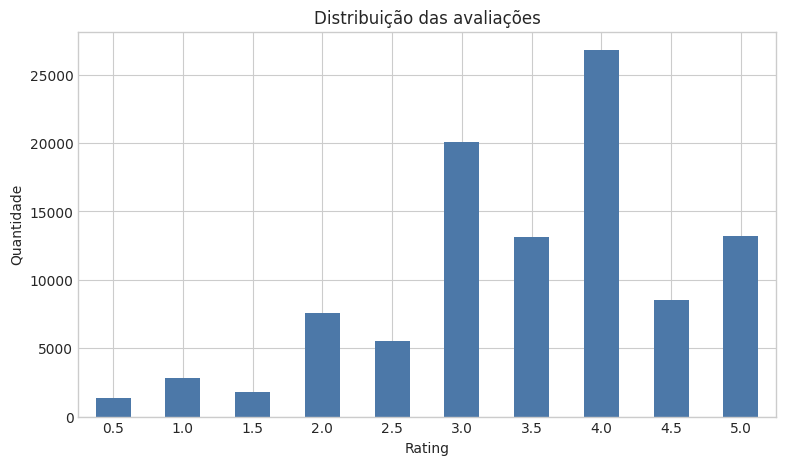

,rating
count,"100,836.00"
mean,3.50
std,1.04
min,0.50
25%,3.00
50%,3.50
75%,4.00
max,5.00


In [5]:
rating_distribution = ratings["rating"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 5))
rating_distribution.plot.bar(ax=ax, color="#4C78A8")
ax.set(title="Distribuição das avaliações", xlabel="Rating", ylabel="Quantidade")
ax.tick_params(axis="x", rotation=0)
plt.show()

ratings["rating"].describe().to_frame(name="rating")

In [6]:
relevant_mask = ratings["rating"] >= 4.0
pd.Series(
    {
        "relevant_ratings": int(relevant_mask.sum()),
        "non_relevant_ratings": int((~relevant_mask).sum()),
        "relevant_pct": relevant_mask.mean() * 100,
    },
    name="value",
).to_frame()

,value
relevant_ratings,"48,580.00"
non_relevant_ratings,"52,256.00"
relevant_pct,48.18


## Atividade dos usuários

Usuários com pouco histórico são mais difíceis de personalizar e representam um cenário de cold start.

,rating_count
count,610.00
mean,165.30
std,269.48
min,20.00
25%,35.00
50%,70.50
75%,168.00
90%,400.30
95%,610.75
max,"2,698.00"


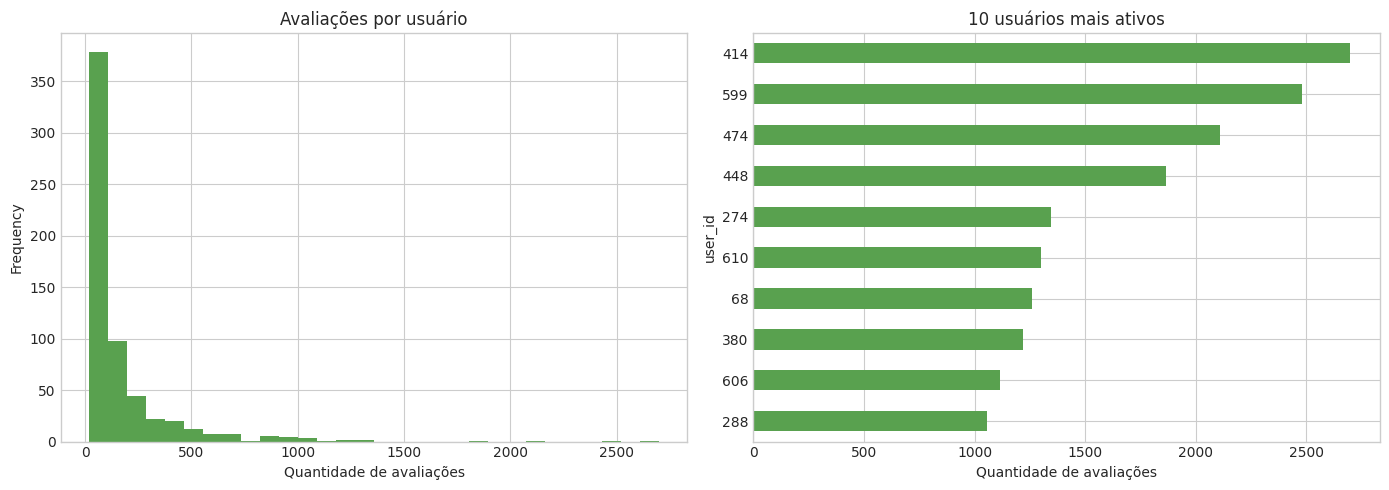

In [7]:
ratings_per_user = ratings.groupby("user_id").size().rename("rating_count")
display(ratings_per_user.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).to_frame())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ratings_per_user.plot.hist(bins=30, ax=axes[0], color="#59A14F")
axes[0].set(title="Avaliações por usuário", xlabel="Quantidade de avaliações")
ratings_per_user.sort_values(ascending=False).head(10).sort_values().plot.barh(
    ax=axes[1], color="#59A14F"
)
axes[1].set(title="10 usuários mais ativos", xlabel="Quantidade de avaliações")
plt.tight_layout()
plt.show()

## Popularidade e qualidade dos filmes

Quantidade de avaliações mede popularidade; média das notas mede satisfação observada. Uma média alta baseada em poucas avaliações não deve ser interpretada como evidência forte.

In [8]:
movie_stats = (
    ratings.groupby("movie_id")
    .agg(rating_count=("rating", "size"), rating_mean=("rating", "mean"))
    .reset_index()
    .merge(movies[["movie_id", "title", "genres"]], on="movie_id", how="left")
)

display(movie_stats.nlargest(10, "rating_count")[["title", "rating_count", "rating_mean"]])

,title,rating_count,rating_mean
314,Forrest Gump (1994),329,4.16
277,"Shawshank Redemption, The (1994)",317,4.43
257,Pulp Fiction (1994),307,4.20
510,"Silence of the Lambs, The (1991)",279,4.16
1938,"Matrix, The (1999)",278,4.19
224,Star Wars: Episode IV - A New Hope (1977),251,4.23
418,Jurassic Park (1993),238,3.75
97,Braveheart (1995),237,4.03
507,Terminator 2: Judgment Day (1991),224,3.97
461,Schindler's List (1993),220,4.22


In [9]:
minimum_ratings = 20
best_supported_movies = (
    movie_stats.query("rating_count >= @minimum_ratings")
    .nlargest(10, "rating_mean")
    [["title", "rating_count", "rating_mean"]]
)
best_supported_movies

,title,rating_count,rating_mean
840,"Streetcar Named Desire, A (1951)",20,4.47
277,"Shawshank Redemption, The (1994)",317,4.43
704,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),27,4.33
680,"Philadelphia Story, The (1940)",29,4.31
413,In the Name of the Father (1993),25,4.30
905,Lawrence of Arabia (1962),45,4.30
210,Hoop Dreams (1994),29,4.29
659,"Godfather, The (1972)",192,4.29
934,Harold and Maude (1971),26,4.29
9445,Logan (2017),25,4.28


## Cauda longa

O gráfico ordena os filmes por popularidade. A escala logarítmica evidencia a diferença entre poucos itens muito conhecidos e muitos itens com poucas avaliações.

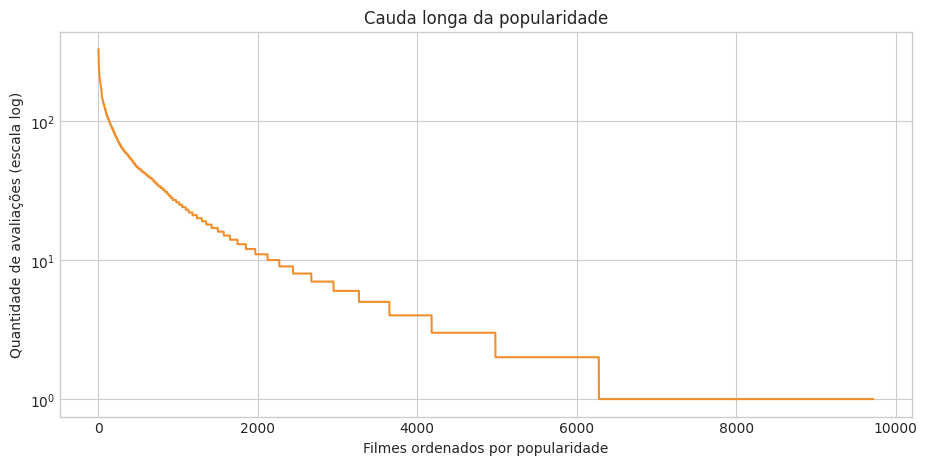

In [10]:
popularity = movie_stats["rating_count"].sort_values(ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(popularity.index, popularity.values, color="#F28E2B")
ax.set_yscale("log")
ax.set(
    title="Cauda longa da popularidade",
    xlabel="Filmes ordenados por popularidade",
    ylabel="Quantidade de avaliações (escala log)",
)
plt.show()

## Gêneros

Como um filme pode pertencer a vários gêneros, a explosão das listas multiplica linhas apenas nesta análise. Ela não substitui a tabela original de ratings.

,rating_count,rating_mean
genre,,
Drama,41928,3.66
Comedy,39053,3.38
Action,30635,3.45
Thriller,26452,3.49
Adventure,24161,3.51
Romance,18124,3.51
Sci-Fi,17243,3.46
Crime,16681,3.66
Fantasy,11834,3.49


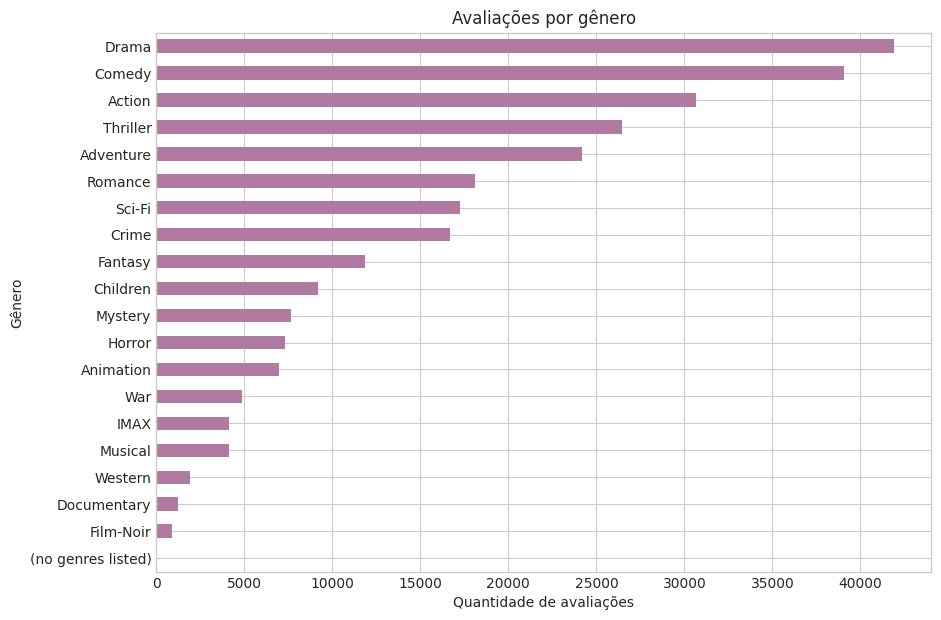

In [11]:
movie_genres = movies.assign(genre=movies["genres"].str.split("|")).explode("genre")
ratings_with_genres = ratings.merge(
    movie_genres[["movie_id", "genre"]], on="movie_id", how="left"
)

genre_stats = (
    ratings_with_genres.groupby("genre")
    .agg(rating_count=("rating", "size"), rating_mean=("rating", "mean"))
    .sort_values("rating_count", ascending=False)
)
display(genre_stats)

fig, ax = plt.subplots(figsize=(10, 7))
genre_stats["rating_count"].sort_values().plot.barh(ax=ax, color="#B07AA1")
ax.set(title="Avaliações por gênero", xlabel="Quantidade de avaliações", ylabel="Gênero")
plt.show()

## Tags sem multiplicar avaliações

Tags são primeiro normalizadas e agregadas por filme. O resultado tem no máximo uma linha por `movie_id` e pode ser unido ao catálogo com segurança.

In [12]:
tags_clean = tags.assign(tag=tags["tag"].str.lower().str.strip())
tags_by_movie = (
    tags_clean.groupby("movie_id")["tag"]
    .agg(lambda values: " | ".join(sorted(set(values))))
    .reset_index(name="tags_text")
)
movie_content = movies.merge(tags_by_movie, on="movie_id", how="left")

assert tags_by_movie["movie_id"].is_unique
assert len(movie_content) == len(movies)

pd.Series(
    {
        "raw_tag_rows": len(tags),
        "movies_with_tags": len(tags_by_movie),
        "catalog_rows_after_join": len(movie_content),
    },
    name="value",
).to_frame()

,value
raw_tag_rows,3683
movies_with_tags,1572
catalog_rows_after_join,9742


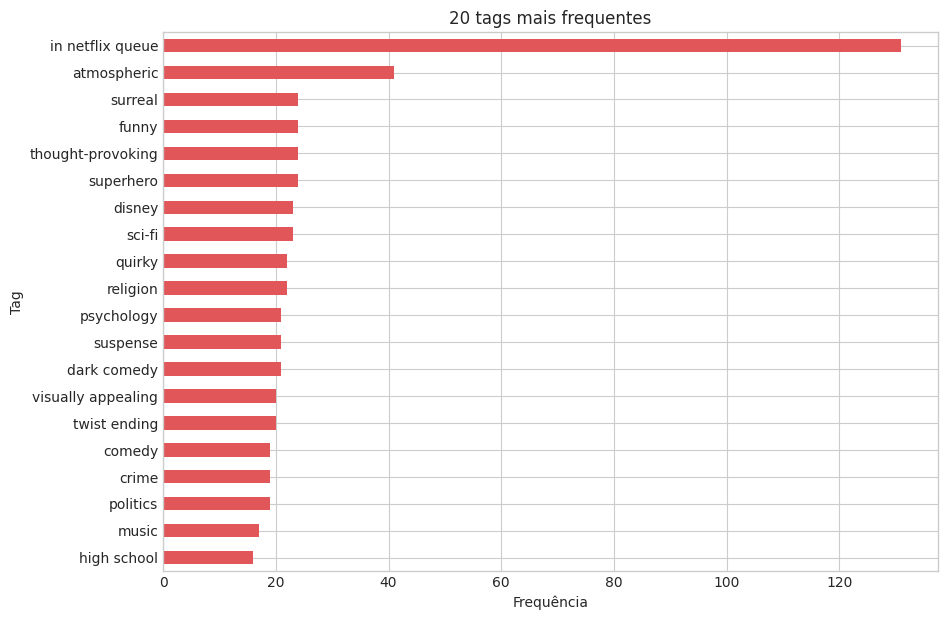

In [13]:
top_tags = tags_clean["tag"].value_counts().head(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
top_tags.plot.barh(ax=ax, color="#E15759")
ax.set(title="20 tags mais frequentes", xlabel="Frequência", ylabel="Tag")
plt.show()

## Comportamento temporal

O tempo será importante para criar treino, validação e teste sem usar o futuro para prever o passado.

,value
first_rating_at,1996-03-29 18:36:55+00:00
last_rating_at,2018-09-24 14:27:30+00:00
distinct_days,4110


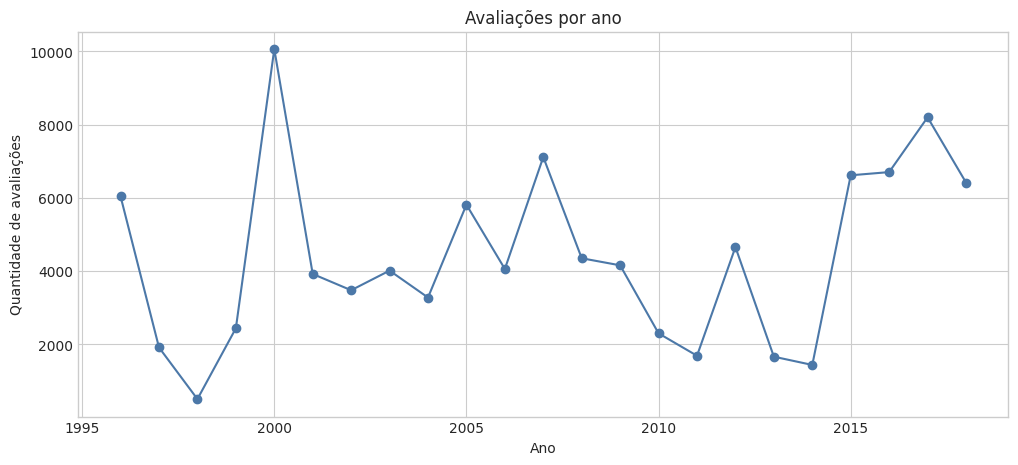

In [14]:
ratings_temporal = ratings.assign(
    rated_at=pd.to_datetime(ratings["timestamp"], unit="s", utc=True)
)
ratings_temporal["rating_year"] = ratings_temporal["rated_at"].dt.year
ratings_by_year = ratings_temporal.groupby("rating_year").size()

display(
    pd.Series(
        {
            "first_rating_at": ratings_temporal["rated_at"].min(),
            "last_rating_at": ratings_temporal["rated_at"].max(),
            "distinct_days": ratings_temporal["rated_at"].dt.date.nunique(),
        },
        name="value",
    ).to_frame()
)

fig, ax = plt.subplots(figsize=(12, 5))
ratings_by_year.plot(ax=ax, marker="o", color="#4C78A8")
ax.set(title="Avaliações por ano", xlabel="Ano", ylabel="Quantidade de avaliações")
plt.show()

## Viabilidade do split temporal por usuário

Antes de reservar as últimas interações, verificamos quantos usuários possuem histórico suficiente.

In [15]:
user_history_sizes = ratings_temporal.groupby("user_id").size()
pd.Series(
    {
        "users_with_at_least_3_ratings": int((user_history_sizes >= 3).sum()),
        "users_with_at_least_5_ratings": int((user_history_sizes >= 5).sum()),
        "users_with_at_least_10_ratings": int((user_history_sizes >= 10).sum()),
        "minimum_user_history": int(user_history_sizes.min()),
    },
    name="value",
).to_frame()

,value
users_with_at_least_3_ratings,610
users_with_at_least_5_ratings,610
users_with_at_least_10_ratings,610
minimum_user_history,20


## Decisões para a primeira versão

- **Feedback principal:** explícito, com previsão de rating.
- **Relevância para Top-K:** `rating >= 4`.
- **Split recomendado:** temporal por usuário; treino com o passado, validação e teste com interações posteriores.
- **Baseline inicial:** popularidade calculada somente com os dados de treino e aplicada apenas a filmes ainda não vistos.
- **Primeiro modelo personalizado:** embeddings de usuário e filme.
- **Modelo híbrido posterior:** incorporar gêneros e tags agregadas por filme.
- **Cold start:** usuários sem histórico recebem o baseline de popularidade; filmes sem interações dependem de features de conteúdo.

## Próximo notebook

Construir um baseline de popularidade com split temporal e avaliá-lo com Precision@10 e Recall@10.